# Experimentos 7 y 8: ConvNeXt solo + ConvNeXt + metadata
**Backbone:** ConvNeXt-Base pretrained en ImageNet-1k (torchvision)  
**Estrategia:** Backbone congelado + linear probe (igual que CLIP y DINOv2)  
**Dataset:** PAD-UFES-20 — clasificación binaria (maligno vs benigno)  
**Referencia:** Liu et al. (2022) — A ConvNet for the 2020s

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torchvision.transforms as T
import torchvision.models as models

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Dispositivo: cuda
GPU: Tesla T4


## 1. Rutas

In [3]:
BASE_PATH    = '/content/drive/MyDrive/PFC1 - Noemi/dataset/PAD-UFES-20'
IMGS_DIR     = os.path.join(BASE_PATH, 'images')
RESULTS_PATH = os.path.join(BASE_PATH, 'resultados')

img_index = {}
for part in ['imgs_part_1', 'imgs_part_2', 'imgs_part_3']:
    part_path = os.path.join(IMGS_DIR, part)
    for fname in os.listdir(part_path):
        img_index[fname] = os.path.join(part_path, fname)

print(f'Imágenes indexadas: {len(img_index)}')

Imágenes indexadas: 2298


## 2. Cargar splits y labels

In [4]:
df_train = pd.read_csv(os.path.join(BASE_PATH, 'split_train.csv'))
df_val   = pd.read_csv(os.path.join(BASE_PATH, 'split_val.csv'))
df_test  = pd.read_csv(os.path.join(BASE_PATH, 'split_test.csv'))

for df in [df_train, df_val, df_test]:
    df['img_path'] = df['img_id'].map(img_index)

y_train = np.load(os.path.join(RESULTS_PATH, 'y_train.npy'))
y_val   = np.load(os.path.join(RESULTS_PATH, 'y_val.npy'))
y_test  = np.load(os.path.join(RESULTS_PATH, 'y_test.npy'))

print(f'Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}')

Train: 1838 | Val: 230 | Test: 230


## 3. Cargar ConvNeXt-Base congelado

In [5]:
# ConvNeXt-Base pretrained en ImageNet-1k
convnext = models.convnext_base(weights=models.ConvNeXt_Base_Weights.IMAGENET1K_V1)

# Quitar la cabeza de clasificación — quedamos con el feature extractor
# ConvNeXt-Base: avgpool → flatten → 1024 dimensiones
convnext.classifier = nn.Identity()
convnext = convnext.to(device)
convnext.eval()

# Congelar backbone
for param in convnext.parameters():
    param.requires_grad = False

# Preprocesamiento estándar ConvNeXt (ImageNet stats)
convnext_preprocess = T.Compose([
    T.Resize(232),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

print('ConvNeXt-Base cargado y congelado')

Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth


100%|██████████| 338M/338M [00:01<00:00, 189MB/s]


ConvNeXt-Base cargado y congelado


## 4. Dataset

In [6]:
class SkinDataset(Dataset):
    def __init__(self, df, transform):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['img_path']).convert('RGB')
        img = self.transform(img)
        label = torch.tensor(row['label'], dtype=torch.float32)
        return img, label

## 5. Pre-extraer embeddings ConvNeXt (una sola vez)

In [7]:
def extract_convnext_embeddings(df, model, preprocess, device, batch_size=64):
    dataset    = SkinDataset(df, preprocess)
    loader     = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    embeddings = []
    model.eval()
    with torch.no_grad():
        for imgs, _ in tqdm(loader):
            imgs  = imgs.to(device)
            feats = model(imgs)  # [B, 1024]
            # Aplanar si es necesario
            if feats.dim() > 2:
                feats = feats.flatten(1)
            feats = feats / feats.norm(dim=-1, keepdim=True)
            embeddings.append(feats.cpu().numpy())
    return np.concatenate(embeddings)

convnext_train_path = os.path.join(RESULTS_PATH, 'convnext_X_train.npy')

if os.path.exists(convnext_train_path):
    print('Embeddings ConvNeXt ya existen, cargando...')
    X_convnext_train = np.load(os.path.join(RESULTS_PATH, 'convnext_X_train.npy'))
    X_convnext_val   = np.load(os.path.join(RESULTS_PATH, 'convnext_X_val.npy'))
    X_convnext_test  = np.load(os.path.join(RESULTS_PATH, 'convnext_X_test.npy'))
else:
    print('Extrayendo embeddings ConvNeXt...')
    print('Train...')
    X_convnext_train = extract_convnext_embeddings(df_train, convnext, convnext_preprocess, device)
    print('Val...')
    X_convnext_val   = extract_convnext_embeddings(df_val,   convnext, convnext_preprocess, device)
    print('Test...')
    X_convnext_test  = extract_convnext_embeddings(df_test,  convnext, convnext_preprocess, device)

    np.save(os.path.join(RESULTS_PATH, 'convnext_X_train.npy'), X_convnext_train)
    np.save(os.path.join(RESULTS_PATH, 'convnext_X_val.npy'),   X_convnext_val)
    np.save(os.path.join(RESULTS_PATH, 'convnext_X_test.npy'),  X_convnext_test)

print(f'X_train: {X_convnext_train.shape} | X_val: {X_convnext_val.shape} | X_test: {X_convnext_test.shape}')

Embeddings ConvNeXt ya existen, cargando...
X_train: (1838, 1024) | X_val: (230, 1024) | X_test: (230, 1024)


## 6. Función de entrenamiento reutilizable

In [8]:
def run_experiment(X_train, X_val, X_test, y_train, y_val, y_test,
                   nombre, epochs=30, lr=1e-3, patience=10):
    input_dim = X_train.shape[1]

    train_loader = DataLoader(
        TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
        batch_size=64, shuffle=True)
    val_loader = DataLoader(
        TensorDataset(torch.tensor(X_val), torch.tensor(y_val)),
        batch_size=64, shuffle=False)
    test_loader = DataLoader(
        TensorDataset(torch.tensor(X_test), torch.tensor(y_test)),
        batch_size=64, shuffle=False)

    head = nn.Sequential(
        nn.Linear(input_dim, 512), nn.ReLU(), nn.Dropout(0.3),
        nn.Linear(512, 256),       nn.ReLU(), nn.Dropout(0.3),
        nn.Linear(256, 1)
    ).to(device)

    criterion  = nn.BCEWithLogitsLoss()
    optimizer  = torch.optim.Adam(head.parameters(), lr=lr, weight_decay=1e-4)
    scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    best_auc   = 0
    pat_count  = 0
    best_path  = os.path.join(RESULTS_PATH, f'{nombre}_head.pt')
    history    = {'train_loss': [], 'val_loss': [], 'val_auc': []}

    print(f'\n{"="*50}\n  {nombre} — input dim: {input_dim}\n{"="*50}')

    for epoch in range(epochs):
        head.train()
        train_loss = 0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            loss = criterion(head(X_b).squeeze(1), y_b)
            loss.backward(); optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        head.eval()
        val_loss, vprobs, vlabels = 0, [], []
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                out = head(X_b).squeeze(1)
                val_loss += criterion(out, y_b).item()
                vprobs.extend(torch.sigmoid(out).cpu().numpy())
                vlabels.extend(y_b.cpu().numpy())
        val_loss /= len(val_loader)
        val_auc   = roc_auc_score(vlabels, vprobs)
        scheduler.step(val_loss)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_auc'].append(val_auc)
        print(f'Epoch {epoch+1:02d} | Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f}')

        if val_auc > best_auc:
            best_auc = val_auc
            torch.save(head.state_dict(), best_path)
            pat_count = 0
            print(f'  Mejor (AUC={best_auc:.4f})')
        else:
            pat_count += 1
            if pat_count >= patience:
                print(f' Early stopping epoch {epoch+1}')
                break

    # Evaluación test
    head.load_state_dict(torch.load(best_path))
    head.eval()
    tprobs, tlabels = [], []
    with torch.no_grad():
        for X_b, y_b in test_loader:
            out = head(X_b.to(device)).squeeze(1)
            tprobs.extend(torch.sigmoid(out).cpu().numpy())
            tlabels.extend(y_b.numpy())

    tprobs = np.array(tprobs); tlabels = np.array(tlabels)
    tpreds = (tprobs >= 0.5).astype(int)

    auc = roc_auc_score(tlabels, tprobs)
    acc = accuracy_score(tlabels, tpreds)
    pre = precision_score(tlabels, tpreds)
    rec = recall_score(tlabels, tpreds)
    f1  = f1_score(tlabels, tpreds)

    print(f'\nRESULTADOS — {nombre}')
    print(f'  AUC: {auc:.4f} | Acc: {acc*100:.1f}% | Pre: {pre*100:.1f}% | Rec: {rec*100:.1f}% | F1: {f1:.4f}')
    print(classification_report(tlabels, tpreds, target_names=['Benigno', 'Maligno']))

    # Matriz confusión
    cm = confusion_matrix(tlabels, tpreds)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=['Benigno','Maligno'],
                yticklabels=['Benigno','Maligno'], ax=ax)
    ax.set_title(f'Confusión — {nombre}', fontweight='bold')
    ax.set_ylabel('Real'); ax.set_xlabel('Predicho')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_PATH, f'{nombre}_confusion.png'), dpi=150, bbox_inches='tight')
    plt.show()

    return {'modelo': nombre, 'auc': round(auc,4), 'accuracy': round(acc,4),
            'precision': round(pre,4), 'recall': round(rec,4), 'f1': round(f1,4)}

print('Función lista')

Función lista


## 7. Experimento 7 — ConvNeXt solo


  convnext_solo — input dim: 1024
Epoch 01 | Loss: 0.6428 | Val Loss: 0.5901 | Val AUC: 0.7886
  Mejor (AUC=0.7886)
Epoch 02 | Loss: 0.5314 | Val Loss: 0.5379 | Val AUC: 0.8127
  Mejor (AUC=0.8127)
Epoch 03 | Loss: 0.4797 | Val Loss: 0.5113 | Val AUC: 0.8323
  Mejor (AUC=0.8323)
Epoch 04 | Loss: 0.4478 | Val Loss: 0.4958 | Val AUC: 0.8408
  Mejor (AUC=0.8408)
Epoch 05 | Loss: 0.4226 | Val Loss: 0.5126 | Val AUC: 0.8616
  Mejor (AUC=0.8616)
Epoch 06 | Loss: 0.4253 | Val Loss: 0.4946 | Val AUC: 0.8622
  Mejor (AUC=0.8622)
Epoch 07 | Loss: 0.3868 | Val Loss: 0.4623 | Val AUC: 0.8668
  Mejor (AUC=0.8668)
Epoch 08 | Loss: 0.3742 | Val Loss: 0.4672 | Val AUC: 0.8696
  Mejor (AUC=0.8696)
Epoch 09 | Loss: 0.3515 | Val Loss: 0.4949 | Val AUC: 0.8752
  Mejor (AUC=0.8752)
Epoch 10 | Loss: 0.3465 | Val Loss: 0.4597 | Val AUC: 0.8768
  Mejor (AUC=0.8768)
Epoch 11 | Loss: 0.3335 | Val Loss: 0.4452 | Val AUC: 0.8797
  Mejor (AUC=0.8797)
Epoch 12 | Loss: 0.3171 | Val Loss: 0.4747 | Val AUC: 0.8726
Ep

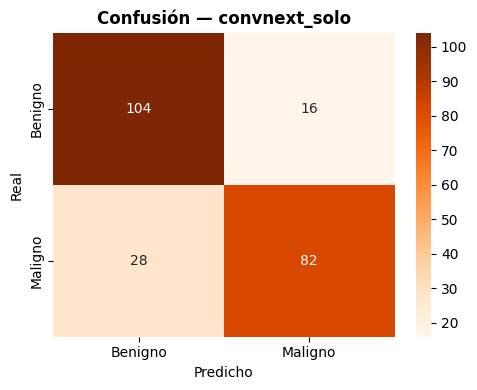

Guardado


In [9]:
results_convnext = run_experiment(
    X_convnext_train, X_convnext_val, X_convnext_test,
    y_train, y_val, y_test,
    nombre='convnext_solo'
)
pd.DataFrame([results_convnext]).to_csv(
    os.path.join(RESULTS_PATH, 'resultados_convnext_solo.csv'), index=False
)
print('Guardado')

## 8. Preprocesar metadata

In [10]:
META_COLS = [
    'smoke', 'drink', 'pesticide', 'gender',
    'skin_cancer_history', 'cancer_history',
    'has_piped_water', 'has_sewage_system',
    'age', 'fitspatrick', 'diameter_1', 'diameter_2',
    'region', 'background_father', 'background_mother',
    'itch', 'grew', 'hurt', 'changed', 'bleed', 'elevation'
]
NUM_COLS = ['age', 'fitspatrick', 'diameter_1', 'diameter_2']
CAT_COLS = [c for c in META_COLS if c not in NUM_COLS]

def preprocess_metadata(df_train, df_val, df_test, meta_cols, num_cols, cat_cols):
    tr = df_train[meta_cols].copy()
    va = df_val[meta_cols].copy()
    te = df_test[meta_cols].copy()
    scaler = MinMaxScaler()
    tr[num_cols] = scaler.fit_transform(tr[num_cols])
    va[num_cols] = scaler.transform(va[num_cols])
    te[num_cols] = scaler.transform(te[num_cols])
    for df in [tr, va, te]:
        for col in df.select_dtypes(include='bool').columns:
            df[col] = df[col].astype(int)
    string_cats = [c for c in cat_cols if tr[c].dtype == object]
    tr_enc = pd.get_dummies(tr, columns=string_cats)
    va_enc = pd.get_dummies(va, columns=string_cats)
    te_enc = pd.get_dummies(te, columns=string_cats)
    va_enc = va_enc.reindex(columns=tr_enc.columns, fill_value=0)
    te_enc = te_enc.reindex(columns=tr_enc.columns, fill_value=0)
    return tr_enc.values.astype(np.float32), va_enc.values.astype(np.float32), te_enc.values.astype(np.float32)

M_train, M_val, M_test = preprocess_metadata(df_train, df_val, df_test, META_COLS, NUM_COLS, CAT_COLS)
print(f'Metadata: {M_train.shape}')

Metadata: (1838, 69)


## 9. Experimento 8 — ConvNeXt + metadata limpia

Dimensión: 1024 (ConvNeXt) + 69 (metadata) = 1093

  convnext_metadata — input dim: 1093
Epoch 01 | Loss: 0.4408 | Val Loss: 0.2968 | Val AUC: 0.9529
  Mejor (AUC=0.9529)
Epoch 02 | Loss: 0.2733 | Val Loss: 0.3503 | Val AUC: 0.9586
  Mejor (AUC=0.9586)
Epoch 03 | Loss: 0.2633 | Val Loss: 0.2760 | Val AUC: 0.9596
  Mejor (AUC=0.9596)
Epoch 04 | Loss: 0.2340 | Val Loss: 0.2694 | Val AUC: 0.9581
Epoch 05 | Loss: 0.2285 | Val Loss: 0.3138 | Val AUC: 0.9608
  Mejor (AUC=0.9608)
Epoch 06 | Loss: 0.2125 | Val Loss: 0.2763 | Val AUC: 0.9565
Epoch 07 | Loss: 0.1921 | Val Loss: 0.2693 | Val AUC: 0.9602
Epoch 08 | Loss: 0.1696 | Val Loss: 0.2629 | Val AUC: 0.9595
Epoch 09 | Loss: 0.1544 | Val Loss: 0.2543 | Val AUC: 0.9605
Epoch 10 | Loss: 0.1511 | Val Loss: 0.2854 | Val AUC: 0.9620
  Mejor (AUC=0.9620)
Epoch 11 | Loss: 0.1219 | Val Loss: 0.2611 | Val AUC: 0.9592
Epoch 12 | Loss: 0.1076 | Val Loss: 0.2666 | Val AUC: 0.9597
Epoch 13 | Loss: 0.0995 | Val Loss: 0.2604 | Val AUC: 0.9615
Epoch 14 | Lo

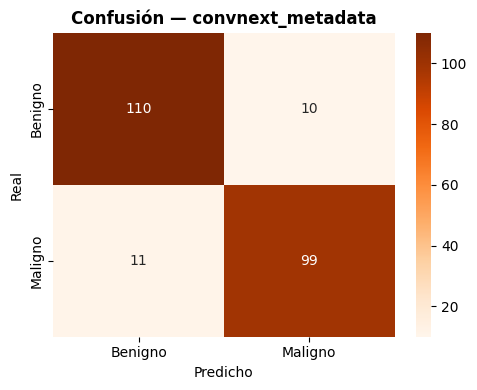

Guardado


In [11]:
X_tr_conv_meta = np.concatenate([X_convnext_train, M_train], axis=1)
X_v_conv_meta  = np.concatenate([X_convnext_val,   M_val],   axis=1)
X_te_conv_meta = np.concatenate([X_convnext_test,  M_test],  axis=1)

print(f'Dimensión: {X_convnext_train.shape[1]} (ConvNeXt) + {M_train.shape[1]} (metadata) = {X_tr_conv_meta.shape[1]}')

results_convnext_meta = run_experiment(
    X_tr_conv_meta, X_v_conv_meta, X_te_conv_meta,
    y_train, y_val, y_test,
    nombre='convnext_metadata'
)
pd.DataFrame([results_convnext_meta]).to_csv(
    os.path.join(RESULTS_PATH, 'resultados_convnext_metadata.csv'), index=False
)
print('Guardado')

## 10. Resumen

In [12]:
resumen = pd.DataFrame([results_convnext, results_convnext_meta])
print('\n=== RESUMEN EXPERIMENTOS 7 y 8 ===')
print(resumen.to_string(index=False))


=== RESUMEN EXPERIMENTOS 7 y 8 ===
           modelo    auc  accuracy  precision  recall     f1
    convnext_solo 0.8893    0.8087     0.8367  0.7455 0.7885
convnext_metadata 0.9569    0.9087     0.9083  0.9000 0.9041
